# Proyecto Final - Notebook 02
## Baseline de modelado: `MobileNetV2 + GRU`

Este notebook construye el primer modelo completo de `image captioning` del proyecto.

Objetivo del baseline:
- usar una `CNN` preentrenada como encoder visual,
- usar una `GRU` como decoder secuencial,
- generar captions palabra a palabra con `greedy decoding`.

Este baseline ya responde a una parte importante de la rubrica:
1. seleccion del modelo,
2. desarrollo y calibracion inicial,
3. visualizacion preliminar de resultados,
4. implementacion de inferencia sobre imagenes nuevas.


In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices("GPU"))


2.10.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from pathlib import Path
import os
import json
import pickle
from tempfile import gettempdir

os.environ.setdefault('MPLCONFIGDIR', str(Path(gettempdir()) / 'matplotlib-cache-project-final'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.image import imread
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Add, Dense, Dropout, Embedding, GRU, Input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer, tokenizer_from_json
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

In [3]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = ROOT / 'data' / 'raw'
IMG_DIR = RAW_DIR / 'Images'
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR = ROOT / 'models'
PREDICTIONS_DIR = ROOT / 'outputs' / 'predictions'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

CAPTIONS_CLEAN_PATH = PROCESSED_DIR / 'captions_clean_split.csv'
SUMMARY_PATH = PROCESSED_DIR / 'preprocessing_summary.json'
TOKENIZER_JSON_PATH = PROCESSED_DIR / 'tokenizer.json'
TOKENIZER_PKL_PATH = PROCESSED_DIR / 'tokenizer.pkl'
FEATURES_PATH = PROCESSED_DIR / 'image_features_mobilenetv2.pkl'

print('ROOT =', ROOT)
print('TOKENIZER_JSON_PATH =', TOKENIZER_JSON_PATH)
print('FEATURES_PATH =', FEATURES_PATH)

ROOT = /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning
TOKENIZER_JSON_PATH = /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning/data/processed/tokenizer.json
FEATURES_PATH = /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning/data/processed/image_features_mobilenetv2.pkl


In [4]:
df = pd.read_csv(CAPTIONS_CLEAN_PATH)
with open(SUMMARY_PATH, 'r', encoding='utf-8') as f:
    preprocessing_summary = json.load(f)


def load_or_rebuild_tokenizer(dataframe):
    # Formato principal: JSON, porque es estable entre versiones de Keras/TensorFlow.
    if TOKENIZER_JSON_PATH.exists():
        return tokenizer_from_json(TOKENIZER_JSON_PATH.read_text(encoding='utf-8'))

    # Fallback: intentar cargar el pickle antiguo si fue creado en el mismo entorno.
    if TOKENIZER_PKL_PATH.exists():
        try:
            with open(TOKENIZER_PKL_PATH, 'rb') as f:
                return pickle.load(f)
        except ModuleNotFoundError:
            print('tokenizer.pkl es incompatible con este entorno; se reconstruira desde train.')

    # Ultimo recurso: reconstruir el vocabulario usando solo captions de entrenamiento.
    train_texts = dataframe.loc[dataframe['split'] == 'train', 'caption_clean'].astype(str).tolist()
    rebuilt_tokenizer = Tokenizer(oov_token='unk')
    rebuilt_tokenizer.fit_on_texts(train_texts)
    TOKENIZER_JSON_PATH.write_text(rebuilt_tokenizer.to_json(), encoding='utf-8')
    print('Se guardo tokenizer.json reconstruido en', TOKENIZER_JSON_PATH)
    return rebuilt_tokenizer


tokenizer = load_or_rebuild_tokenizer(df)

summary_vocab_size = int(preprocessing_summary['vocab_size'])
tokenizer_vocab_size = len(tokenizer.word_index) + 1
vocab_size = tokenizer_vocab_size
max_len = int(preprocessing_summary['max_len'])

if tokenizer_vocab_size != summary_vocab_size:
    print(f'Advertencia: vocabulario del resumen ({summary_vocab_size}) != vocabulario del tokenizer ({tokenizer_vocab_size}). Se usara el tokenizer.')

train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'val'].copy()
test_df = df[df['split'] == 'test'].copy()

print('train captions =', len(train_df))
print('val captions =', len(val_df))
print('test captions =', len(test_df))
print('vocab_size =', vocab_size)
print('max_len =', max_len)

train captions = 28315
val captions = 6065
test captions = 6075
vocab_size = 7251
max_len = 38


## 1. Encoder visual con `MobileNetV2`

La idea es transformar cada imagen en un vector de caracteristicas usando `transfer learning`.

Decisiones del baseline:
- usar `MobileNetV2` por ser mas liviana que `VGG16`,
- cargar pesos de `ImageNet`,
- remover la cabeza de clasificacion,
- usar `pooling='avg'` para obtener un vector fijo por imagen.

Nota practica:
si es la primera vez que se usa este modelo en la maquina, Keras puede descargar los pesos de `ImageNet`.


In [5]:
def load_image_for_encoder(image_path, target_size=(224, 224)):
    # Cargar y redimensionar la imagen al formato esperado por MobileNetV2.
    image = load_img(image_path, target_size=target_size)
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    return preprocess_input(image)


def build_feature_extractor():
    # `include_top=False` elimina la cabeza original de clasificacion.
    # `pooling='avg'` produce un vector fijo de features por imagen.
    return MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))


In [6]:
def extract_image_features(image_names, batch_size=64):
    extractor = build_feature_extractor()
    features = {}

    for start in range(0, len(image_names), batch_size):
        batch_names = image_names[start:start + batch_size]
        batch_images = [load_image_for_encoder(IMG_DIR / image_name)[0] for image_name in batch_names]
        batch_images = np.stack(batch_images, axis=0)
        batch_features = extractor.predict(batch_images, verbose=0)

        for image_name, feature_vector in zip(batch_names, batch_features):
            features[image_name] = feature_vector.astype('float32')

        if start % (batch_size * 20) == 0:
            print(f'Procesadas {min(start + batch_size, len(image_names))} de {len(image_names)} imagenes')

    return features


In [7]:
all_images = sorted(df['image'].unique())

if FEATURES_PATH.exists():
    with open(FEATURES_PATH, 'rb') as f:
        image_features = pickle.load(f)
    print('Features cargadas desde disco:', len(image_features))
else:
    image_features = extract_image_features(all_images, batch_size=64)
    with open(FEATURES_PATH, 'wb') as f:
        pickle.dump(image_features, f)
    print('Features extraidas y guardadas en:', FEATURES_PATH)


Metal device set to: Apple M1 Max

systemMemory: 32.00 GB
maxCacheSize: 10.67 GB



2026-03-14 17:18:02.037771: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-14 17:18:02.037938: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


9406464/9406464 [==============================] - 1s 0us/step


2026-03-14 17:18:05.938589: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2026-03-14 17:18:06.148135: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Procesadas 64 de 8091 imagenes
Procesadas 1344 de 8091 imagenes
Procesadas 2624 de 8091 imagenes
Procesadas 3904 de 8091 imagenes
Procesadas 5184 de 8091 imagenes
Procesadas 6464 de 8091 imagenes
Procesadas 7744 de 8091 imagenes


2026-03-14 17:18:38.225783: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Features extraidas y guardadas en: /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning/data/processed/image_features_mobilenetv2.pkl


In [8]:
feature_dim = next(iter(image_features.values())).shape[0]
print('feature_dim =', feature_dim)
print('ejemplo vector shape =', image_features[all_images[0]].shape)


feature_dim = 1280
ejemplo vector shape = (1280,)


## 2. Construccion de muestras para next-word prediction

El decoder se entrena con ejemplos del tipo:
- entrada 1: `features` de la imagen,
- entrada 2: secuencia parcial del caption,
- salida: siguiente palabra.

Ejemplo:
- `startseq a dog`
- objetivo: `running`

Esto convierte el problema de generacion de captions en una tarea supervisada de prediccion de la siguiente palabra.


In [9]:
def build_next_word_samples(dataframe, tokenizer):
    # Cada caption produce varios ejemplos parciales para entrenar la generacion autoregresiva.
    samples = []
    for row in dataframe.itertuples(index=False):
        seq = tokenizer.texts_to_sequences([row.caption_clean])[0]
        for i in range(1, len(seq)):
            samples.append((row.image, seq[:i], seq[i]))
    return samples


In [10]:
train_samples = build_next_word_samples(train_df, tokenizer)
val_samples = build_next_word_samples(val_df, tokenizer)

def describe_samples(name, samples):
    seq_lengths = [len(seq) for _, seq, _ in samples]
    print(name)
    print('  num_samples =', len(samples))
    print('  mean_partial_len =', round(float(np.mean(seq_lengths)), 2))
    print('  max_partial_len =', int(np.max(seq_lengths)))


describe_samples('train_samples', train_samples)
describe_samples('val_samples', val_samples)


train_samples
  num_samples = 334223
  mean_partial_len = 7.01
  max_partial_len = 37
val_samples
  num_samples = 71767
  mean_partial_len = 7.01
  max_partial_len = 30


In [11]:
class CaptionDataGenerator(Sequence):
    def __init__(self, samples, image_features, max_len, batch_size=256, shuffle=True):
        self.samples = samples
        self.image_features = image_features
        self.max_len = max_len
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(samples))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_samples = [self.samples[i] for i in batch_indices]

        # Construir el batch en memoria solo para las muestras necesarias en ese paso.
        batch_image = np.array([self.image_features[img_name] for img_name, _, _ in batch_samples], dtype='float32')
        batch_seq = pad_sequences([seq for _, seq, _ in batch_samples], maxlen=self.max_len, padding='post')
        batch_y = np.array([next_word for _, _, next_word in batch_samples], dtype='int32')

        return (batch_image, batch_seq), batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


In [12]:
batch_size = 256

train_gen = CaptionDataGenerator(train_samples, image_features, max_len=max_len, batch_size=batch_size, shuffle=True)
val_gen = CaptionDataGenerator(val_samples, image_features, max_len=max_len, batch_size=batch_size, shuffle=False)

print('train steps =', len(train_gen))
print('val steps =', len(val_gen))


train steps = 1306
val steps = 281


## 3. Decoder `GRU` y ensamblaje del baseline

Arquitectura propuesta:
- `image features -> Dense`
- `partial caption -> Embedding -> GRU`
- combinar ambas ramas con `Add`
- predecir siguiente palabra con `Softmax`

Se usa `sparse_categorical_crossentropy` para evitar convertir la salida a one-hot, lo cual seria muy costoso en memoria con este vocabulario.


In [13]:
embedding_dim = 256
gru_units = 256
learning_rate = 1e-3
epochs = 10

image_input = Input(shape=(feature_dim,), name='image_features')
image_branch = Dropout(0.3)(image_input)
image_branch = Dense(gru_units, activation='relu')(image_branch)

seq_input = Input(shape=(max_len,), name='partial_caption')
seq_branch = Embedding(vocab_size, embedding_dim, mask_zero=True, name='caption_embedding')(seq_input)
seq_branch = Dropout(0.3)(seq_branch)
seq_branch = GRU(gru_units, name='caption_gru')(seq_branch)

# `Add` obliga a que ambas ramas aprendan una representacion compatible del contexto visual y textual.
decoder = Add()([image_branch, seq_branch])
decoder = Dense(gru_units, activation='relu')(decoder)
output = Dense(vocab_size, activation='softmax', name='next_word')(decoder)

model = Model(inputs=[image_input, seq_input], outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 partial_caption (InputLayer)   [(None, 38)]         0           []                               
                                                                                                  
 image_features (InputLayer)    [(None, 1280)]       0           []                               
                                                                                                  
 caption_embedding (Embedding)  (None, 38, 256)      1856256     ['partial_caption[0][0]']        
                                                                                                  
 dropout (Dropout)              (None, 1280)         0           ['image_features[0][0]']         
                                                                                              

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10


2026-03-14 17:18:41.419747: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 17:18:42.361061: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 17:18:46.524515: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1306/1306 [==============================] - ETA: 0s - loss: 4.8365 - sparse_categorical_accuracy: 0.1754

2026-03-14 17:20:29.327273: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 17:20:29.508968: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1306/1306 [==============================] - 119s 85ms/step - loss: 4.8365 - sparse_categorical_accuracy: 0.1754 - val_loss: 3.9951 - val_sparse_categorical_accuracy: 0.2840
Epoch 2/10
1306/1306 [==============================] - 101s 78ms/step - loss: 3.5949 - sparse_categorical_accuracy: 0.3181 - val_loss: 3.5443 - val_sparse_categorical_accuracy: 0.3414
Epoch 3/10
1306/1306 [==============================] - 102s 78ms/step - loss: 3.1700 - sparse_categorical_accuracy: 0.3538 - val_loss: 3.4304 - val_sparse_categorical_accuracy: 0.3579
Epoch 4/10
1306/1306 [==============================] - 101s 77ms/step - loss: 2.9198 - sparse_categorical_accuracy: 0.3737 - val_loss: 3.4488 - val_sparse_categorical_accuracy: 0.3638
Epoch 5/10
1306/1306 [==============================] - 101s 77ms/step - loss: 2.7516 - sparse_categorical_accuracy: 0.3873 - val_loss: 3.5000 - val_sparse_categorical_accuracy: 0.3656


In [15]:
history_df = pd.DataFrame(history.history)
history_df


,loss,sparse_categorical_accuracy,val_loss,val_sparse_categorical_accuracy
0,4.836541,0.175419,3.995052,0.284002
1,3.594935,0.318120,3.544305,0.341438
2,3.170007,0.353803,3.430417,0.357922
3,2.919791,0.373741,3.448763,0.363802
4,2.751554,0.387331,3.499999,0.365586


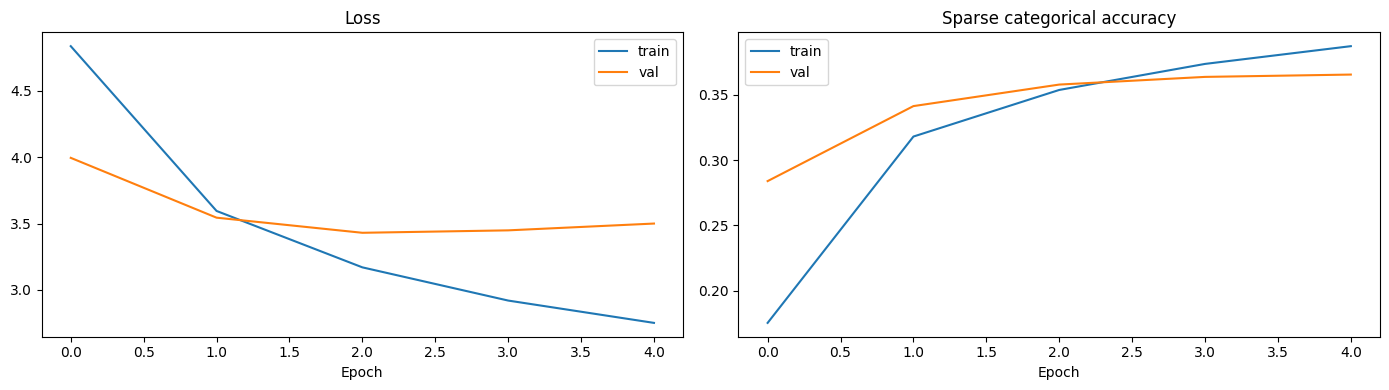

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['sparse_categorical_accuracy'], label='train')
axes[1].plot(history.history['val_sparse_categorical_accuracy'], label='val')
axes[1].set_title('Sparse categorical accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Inferencia con `greedy decoding`

En inferencia se comienza con `startseq` y el modelo va escogiendo la palabra mas probable en cada paso hasta llegar a `endseq` o hasta completar la longitud maxima.

Esta es la version mas simple de decodificacion y es suficiente para el baseline del curso.


In [17]:
index_word = tokenizer.index_word
start_token = tokenizer.word_index['startseq']
end_token = tokenizer.word_index['endseq']


def generate_caption(image_name, model, tokenizer, image_features, max_len):
    feature_vector = image_features[image_name].reshape(1, -1)
    in_seq = [start_token]

    for _ in range(max_len):
        padded_seq = pad_sequences([in_seq], maxlen=max_len, padding='post')
        yhat = model.predict([feature_vector, padded_seq], verbose=0)
        next_idx = int(np.argmax(yhat[0]))

        if next_idx == 0:
            break

        next_word = index_word.get(next_idx, 'unk')
        if next_word == 'endseq':
            break

        in_seq.append(next_idx)

    words = [index_word.get(idx, 'unk') for idx in in_seq if idx not in (start_token, end_token)]
    return ' '.join(words)


def get_reference_captions(image_name, dataframe):
    refs = dataframe.loc[dataframe['image'] == image_name, 'caption_clean'].tolist()
    refs = [caption.replace('startseq ', '').replace(' endseq', '') for caption in refs]
    return refs


2026-03-14 17:29:02.796823: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-14 17:29:03.761355: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


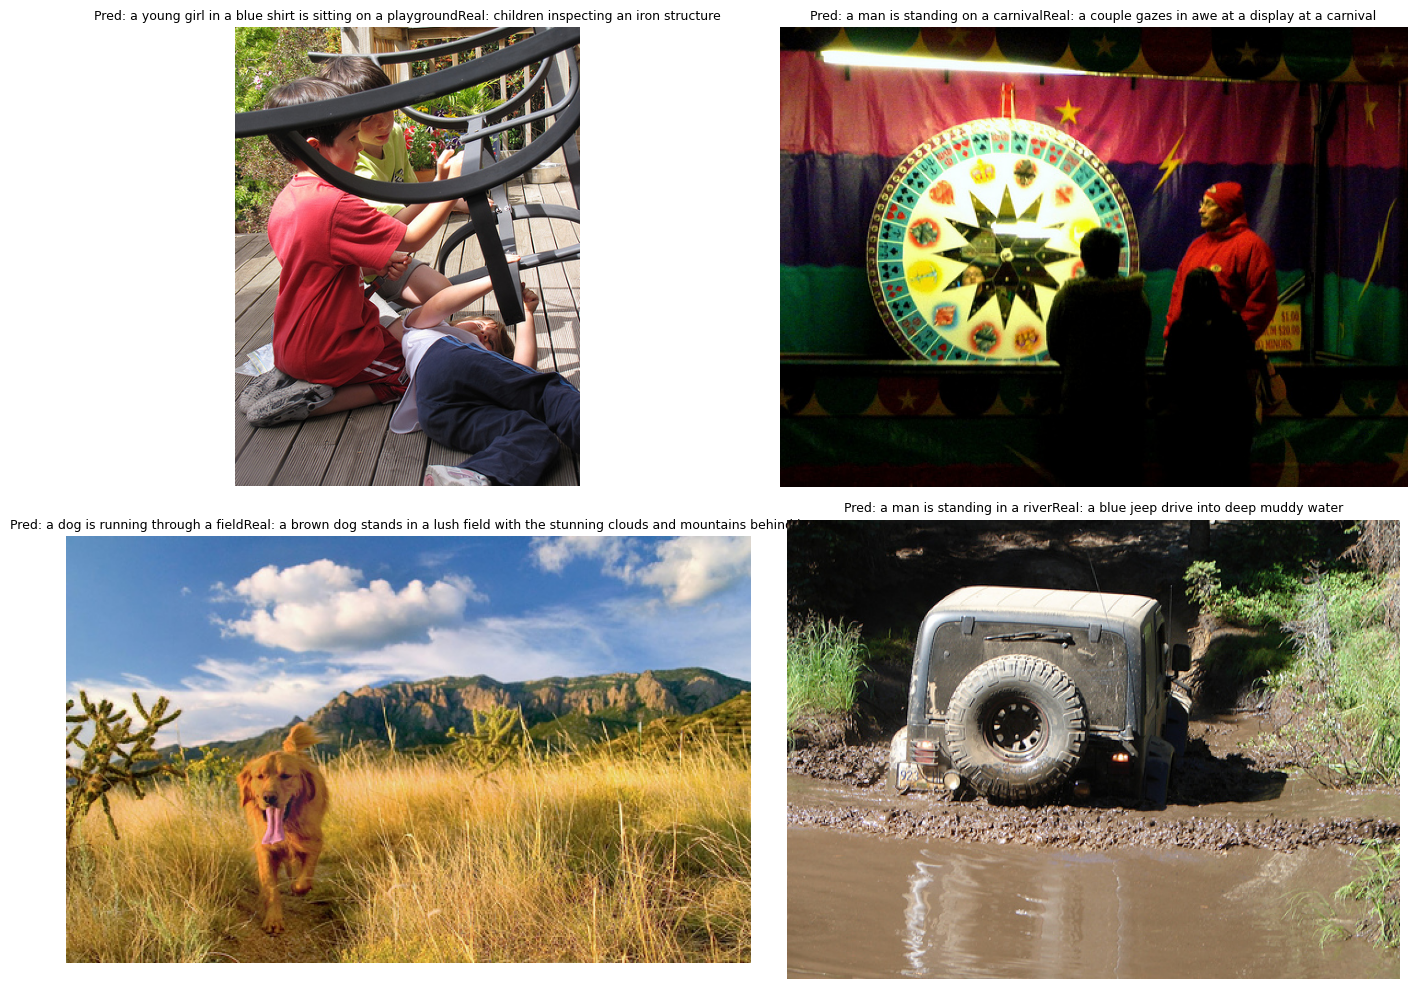

In [19]:
sample_test_images = test_df['image'].drop_duplicates().sample(4, random_state=42).tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, image_name in zip(axes, sample_test_images):
    predicted_caption = generate_caption(image_name, model, tokenizer, image_features, max_len)
    reference_caption = get_reference_captions(image_name, test_df)[0]

    ax.imshow(imread(IMG_DIR / image_name))
    ax.set_title(f'Pred: {predicted_caption}Real: {reference_caption}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [20]:
# Guardar el baseline entrenado para reutilizarlo en calibracion o demo.
model.save(MODELS_DIR / 'baseline_mobilenetv2_gru.keras')
print('Modelo guardado en', MODELS_DIR / 'baseline_mobilenetv2_gru.keras')


Modelo guardado en /Users/danilosuarezvargas/Documents/Maestria Universidad andes/Deep learning/Proyecto_Final_Captioning/models/baseline_mobilenetv2_gru.keras


## 5. Evaluacion opcional con `BLEU`

Si `nltk` esta disponible en el entorno, la siguiente celda calcula `BLEU-1` y `BLEU-2` sobre una muestra de imagenes de test. Para el baseline es suficiente usar una muestra moderada para tener una señal rapida de calidad.


In [21]:
try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

    eval_images = test_df['image'].drop_duplicates().tolist()[:300]
    references = []
    hypotheses = []

    for image_name in eval_images:
        refs = [caption.split() for caption in get_reference_captions(image_name, test_df)]
        hyp = generate_caption(image_name, model, tokenizer, image_features, max_len).split()
        references.append(refs)
        hypotheses.append(hyp)

    smoother = SmoothingFunction().method1
    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoother)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)

    print('BLEU-1 =', round(bleu1, 4))
    print('BLEU-2 =', round(bleu2, 4))
except Exception as exc:
    print('No fue posible calcular BLEU en este entorno:', exc)


BLEU-1 = 0.486
BLEU-2 = 0.3279


## Conclusiones del baseline

- Ya existe un pipeline completo de `image captioning` funcional.
- El encoder visual usa `transfer learning` con `MobileNetV2`.
- El decoder usa `Embedding + GRU` para modelar la secuencia del caption.
- La siguiente fase del proyecto es calibrar variantes del baseline, por ejemplo:
  - `GRU` vs `LSTM`,
  - diferentes dimensiones de embedding,
  - distintos numeros de unidades recurrentes,
  - y eventualmente otro encoder visual.
